<a href="https://colab.research.google.com/github/SohailVibeCoder/IB9AU---GenAI/blob/main/Task_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Sohail Essajee (5757504)

The model does not store or copy existing floorplans; instead, it learns the underlying statistical structure of what a floorplan looks like to construct entirely new, consistent designs.

Random noise serves as the essential starting point for generation, providing the variety and potential required for the model to produce different synthetic floorplans from different noise inputs.

The model is trained to navigate from noise to a realistic image using straight-line steps, effectively giving structure to randomness to create a realistic final output.

----

----

In [ ]:
# =========================
# CELL 1 — Setup
# =========================
import os, glob, zipfile, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = "/content/data"
EXTRACT_DIR = "/content/floorplan_images"

# Find the zip file in /content/data/
zips = sorted(glob.glob(os.path.join(DATA_DIR, "*.zip")))
if not zips:
    raise FileNotFoundError(f"No .zip found in {DATA_DIR}. Put the zip there.")
zip_path = zips[0]
print("Using zip:", zip_path)

# Extract
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

# Quick sanity: count image files
img_exts = ("*.png", "*.jpg", "*.jpeg", "*.webp")
all_imgs = []
for e in img_exts:
    all_imgs += glob.glob(os.path.join(EXTRACT_DIR, "**", e), recursive=True)
print("Found images:", len(all_imgs))
if len(all_imgs) == 0:
    raise RuntimeError("No images found after extraction. Check zip structure.")


Using device: cuda
Using zip: /content/data/floorplans_v2-20251223T170650Z-3-001.zip
Extracted to: /content/floorplan_images
Found images: 1000


In [ ]:
# =========================
# CELL 1.5 — Preprocess
# =========================
import os, glob
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

SRC = EXTRACT_DIR
DST = "/content/floorplans_256"
IMG_SIZE = 256
CHANNELS = 1  # set 3 if you want RGB

os.makedirs(DST, exist_ok=True)

paths = []
for e in ("png","jpg","jpeg","webp"):
    paths += glob.glob(os.path.join(SRC, "**", f"*.{e}"), recursive=True)

print("Found:", len(paths), "raw images")

saved = 0
for i, p in enumerate(paths):
    try:
        img = Image.open(p)
        img = img.convert("L") if CHANNELS == 1 else img.convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
        img.save(os.path.join(DST, f"fp_{i:05d}.png"), optimize=True)
        saved += 1
    except Exception:
        continue

print("Saved preprocessed:", saved, "to", DST)

Found: 1000 raw images
Saved preprocessed: 1000 to /content/floorplans_256


In [ ]:
# =========================
# CELL 2 — Hyperparameters
# =========================

import os, glob, random
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True  # tolerate slightly broken files

# ---- Configure these ----
# If you already ran a preprocess cell that wrote 256x256 PNGs, set this to that folder:
CACHED_DIR = "/content/floorplans_256"   # <-- recommended
# Otherwise, fallback to extracted directory (less stable for huge raw images):
FALLBACK_DIR = EXTRACT_DIR

ROOT_DIR = CACHED_DIR if os.path.exists(CACHED_DIR) and len(glob.glob(CACHED_DIR+"/*.png")) > 0 else FALLBACK_DIR
print("Using ROOT_DIR:", ROOT_DIR)

# Detect channels based on your preference (1 is recommended for floorplans)
CHANNELS = 1  # set 3 for RGB floorplans

HPARAMS = {
    "img_size": 256,                 # use 128 for faster/safer if needed
    "channels": CHANNELS,
    "batch_size": 4,                 # RAM-safe default (increase to 8/16 if stable on GPU)
    "lr": 2e-4,
    "weight_decay": 1e-4,
    "epochs": 20,
    "inference_steps": 100,
    "num_workers": 0,                # IMPORTANT: avoid extra RAM from worker processes
    "pin_memory": (device.type == "cuda"),
    "grad_clip": 1.0,
    "amp": True,                     # only used if CUDA is available
    "base_channels": 64,             # set 32 if you need it lighter
    "num_classes": 1
}

print("HPARAMS:", HPARAMS)

class FloorplanDataset(Dataset):
    def __init__(self, root_dir, img_size=256, channels=1):
        self.paths = []
        for e in ("png", "jpg", "jpeg", "webp"):
            self.paths += glob.glob(os.path.join(root_dir, "**", f"*.{e}"), recursive=True)
        self.paths = sorted(self.paths)
        if not self.paths:
            raise RuntimeError(f"No images found under {root_dir}")

        # If you're using preprocessed cached PNGs, transforms are light.
        # If not, these still work but decoding raw huge images can be RAM-heavy.
        self.transform = T.Compose([
            T.Resize(img_size),
            T.CenterCrop(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.ToTensor(),
        ])
        self.channels = channels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        try:
            img = Image.open(p)
            img = img.convert("L") if self.channels == 1 else img.convert("RGB")
            x = self.transform(img)
        except Exception:
            ridx = random.randint(0, len(self.paths) - 1)
            return self.__getitem__(ridx)

        label = 0
        return x, label

dataset = FloorplanDataset(ROOT_DIR, img_size=HPARAMS["img_size"], channels=HPARAMS["channels"])
loader = DataLoader(
    dataset,
    batch_size=HPARAMS["batch_size"],
    shuffle=True,
    num_workers=HPARAMS["num_workers"],
    pin_memory=HPARAMS["pin_memory"],
    drop_last=True
)

print("Dataset size:", len(dataset))
print("Batches per epoch:", len(loader))
print("Device:", device)

Using ROOT_DIR: /content/floorplans_256
HPARAMS: {'img_size': 256, 'channels': 1, 'batch_size': 4, 'lr': 0.0002, 'weight_decay': 0.0001, 'epochs': 20, 'inference_steps': 100, 'num_workers': 0, 'pin_memory': True, 'grad_clip': 1.0, 'amp': True, 'base_channels': 64, 'num_classes': 1}
Dataset size: 1000
Batches per epoch: 250
Device: cuda


In [ ]:
# =========================
# CELL 3 — Model (UNet)
# =========================

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: (B,) in [0,1]
        half = self.dim // 2
        device = t.device
        freqs = torch.exp(
            torch.linspace(0, np.log(10000), half, device=device) * (-1)
        )
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([args.sin(), args.cos()], dim=-1)
        return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch

        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_dim, out_ch)
        )

        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        # add time embedding
        t = self.time_mlp(t_emb)[:, :, None, None]
        h = h + t
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class ConditionalUNet(nn.Module):
    def __init__(self, img_ch, base_ch, num_classes=1, t_dim=128):
        super().__init__()
        self.num_classes = num_classes

        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(t_dim),
            nn.Linear(t_dim, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        self.class_emb = nn.Embedding(num_classes, t_dim)

        # Encoder
        self.in_conv = nn.Conv2d(img_ch, base_ch, 3, padding=1)

        self.rb1 = ResBlock(base_ch, base_ch, t_dim)
        self.rb2 = ResBlock(base_ch, base_ch, t_dim)
        self.down1 = Downsample(base_ch)

        self.rb3 = ResBlock(base_ch, base_ch*2, t_dim)
        self.rb4 = ResBlock(base_ch*2, base_ch*2, t_dim)
        self.down2 = Downsample(base_ch*2)

        self.rb5 = ResBlock(base_ch*2, base_ch*4, t_dim)
        self.rb6 = ResBlock(base_ch*4, base_ch*4, t_dim)

        # Middle
        self.mid1 = ResBlock(base_ch*4, base_ch*4, t_dim)
        self.mid2 = ResBlock(base_ch*4, base_ch*4, t_dim)

        # Decoder
        self.up1 = Upsample(base_ch*4)
        self.rb7 = ResBlock(base_ch*4 + base_ch*2, base_ch*2, t_dim)
        self.rb8 = ResBlock(base_ch*2, base_ch*2, t_dim)

        self.up2 = Upsample(base_ch*2)
        self.rb9 = ResBlock(base_ch*2 + base_ch, base_ch, t_dim)
        self.rb10 = ResBlock(base_ch, base_ch, t_dim)

        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, img_ch, 1)

    def forward(self, x, t, y):
        # t: (B,) float in [0,1], y: (B,) long
        t_emb = self.time_emb(t) + self.class_emb(y)

        x = self.in_conv(x)

        s1 = self.rb2(self.rb1(x, t_emb), t_emb)   # base
        x  = self.down1(s1)

        s2 = self.rb4(self.rb3(x, t_emb), t_emb)   # base*2
        x  = self.down2(s2)

        x  = self.rb6(self.rb5(x, t_emb), t_emb)   # base*4
        x  = self.mid2(self.mid1(x, t_emb), t_emb)

        x  = self.up1(x)
        x  = torch.cat([x, s2], dim=1)
        x  = self.rb8(self.rb7(x, t_emb), t_emb)

        x  = self.up2(x)
        x  = torch.cat([x, s1], dim=1)
        x  = self.rb10(self.rb9(x, t_emb), t_emb)

        x  = self.out_conv(F.silu(self.out_norm(x)))
        return x

class FlowMatching:
    def compute_loss(self, model, x1, labels):
        b = x1.size(0)
        x0 = torch.randn_like(x1)
        t = torch.rand(b, device=x1.device)  # uniform in [0,1]
        t_view = t.view(b, 1, 1, 1)

        xt = (1 - t_view) * x0 + t_view * x1
        v_target = x1 - x0
        v_pred = model(xt, t, labels)

        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample_euler(self, model, n, class_idx, size, channels, steps=100):
        model.eval()
        x = torch.randn(n, channels, size, size, device=device)
        y = torch.full((n,), class_idx, dtype=torch.long, device=device)

        dt = 1.0 / steps
        for i in range(steps):
            t = torch.full((n,), i / steps, device=device)
            v = model(x, t, y)
            x = x + dt * v

        model.train()
        return x

    @torch.no_grad()
    def sample_heun(self, model, n, class_idx, size, channels, steps=100):
        # Better quality than Euler at same steps (predictor-corrector)
        model.eval()
        x = torch.randn(n, channels, size, size, device=device)
        y = torch.full((n,), class_idx, dtype=torch.long, device=device)

        dt = 1.0 / steps
        for i in range(steps):
            t0 = torch.full((n,), i / steps, device=device)
            t1 = torch.full((n,), (i + 1) / steps, device=device)

            v0 = model(x, t0, y)
            x_pred = x + dt * v0
            v1 = model(x_pred, t1, y)

            x = x + dt * 0.5 * (v0 + v1)

        model.train()
        return x

model = ConditionalUNet(
    img_ch=HPARAMS["channels"],
    base_ch=HPARAMS["base_channels"],
    num_classes=HPARAMS["num_classes"],
    t_dim=128
).to(device)

flow = FlowMatching()

optimizer = torch.optim.AdamW(model.parameters(), lr=HPARAMS["lr"], weight_decay=HPARAMS["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HPARAMS["epochs"])
scaler = torch.cuda.amp.GradScaler(enabled=(HPARAMS["amp"] and device.type == "cuda"))

print(" parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")


Model parameters: 8.211393 M


/tmp/ipython-input-2574895366.py:191: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(HPARAMS["amp"] and device.type == "cuda"))


Epoch 1/20:   0%|          | 0/250 [00:00<?, ?it/s]/tmp/ipython-input-3124157807.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(HPARAMS["amp"] and device.type == "cuda")):
Epoch 1/20: 100%|██████████| 250/250 [01:27<00:00,  2.86it/s, loss=0.0442]


Epoch 1 avg loss: 0.118693


Epoch 2/20: 100%|██████████| 250/250 [01:09<00:00,  3.58it/s, loss=0.0311]


Epoch 2 avg loss: 0.049245


Epoch 3/20: 100%|██████████| 250/250 [01:09<00:00,  3.58it/s, loss=0.0264]


Epoch 3 avg loss: 0.043000


Epoch 4/20: 100%|██████████| 250/250 [01:09<00:00,  3.59it/s, loss=0.0318]


Epoch 4 avg loss: 0.040627


Epoch 5/20: 100%|██████████| 250/250 [01:09<00:00,  3.58it/s, loss=0.0275]


Epoch 5 avg loss: 0.035161


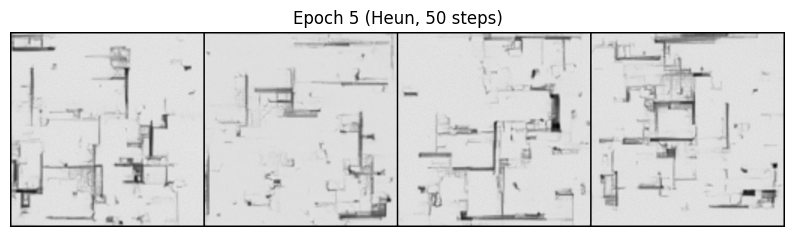

Epoch 6/20: 100%|██████████| 250/250 [01:09<00:00,  3.58it/s, loss=0.0471]


Epoch 6 avg loss: 0.035921


Epoch 7/20: 100%|██████████| 250/250 [01:10<00:00,  3.55it/s, loss=0.0359]


Epoch 7 avg loss: 0.035964


Epoch 8/20: 100%|██████████| 250/250 [01:10<00:00,  3.56it/s, loss=0.0358]


Epoch 8 avg loss: 0.031365


Epoch 9/20: 100%|██████████| 250/250 [01:10<00:00,  3.56it/s, loss=0.0323]


Epoch 9 avg loss: 0.029094


Epoch 10/20: 100%|██████████| 250/250 [01:10<00:00,  3.56it/s, loss=0.0223]


Epoch 10 avg loss: 0.028748


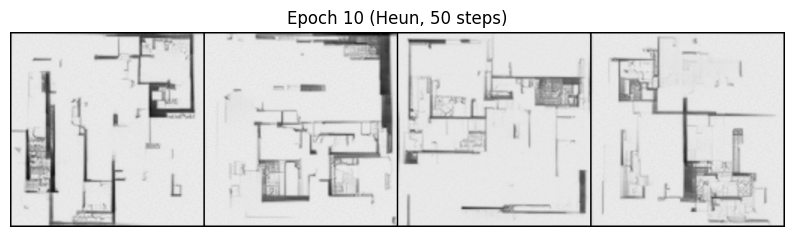

Epoch 11/20: 100%|██████████| 250/250 [01:10<00:00,  3.57it/s, loss=0.0285]


Epoch 11 avg loss: 0.030126


Epoch 12/20: 100%|██████████| 250/250 [01:10<00:00,  3.56it/s, loss=0.0241]


Epoch 12 avg loss: 0.031549


Epoch 13/20: 100%|██████████| 250/250 [01:10<00:00,  3.55it/s, loss=0.0577]


Epoch 13 avg loss: 0.028738


Epoch 14/20: 100%|██████████| 250/250 [01:10<00:00,  3.55it/s, loss=0.0283]


Epoch 14 avg loss: 0.028977


Epoch 15/20: 100%|██████████| 250/250 [01:10<00:00,  3.55it/s, loss=0.021]


Epoch 15 avg loss: 0.028121


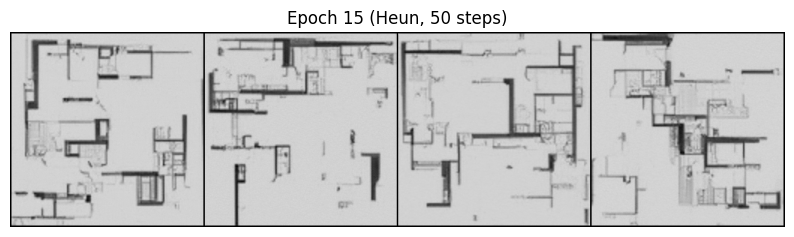

Epoch 16/20: 100%|██████████| 250/250 [01:10<00:00,  3.57it/s, loss=0.0228]


Epoch 16 avg loss: 0.028229


Epoch 17/20: 100%|██████████| 250/250 [01:10<00:00,  3.55it/s, loss=0.0231]


Epoch 17 avg loss: 0.026745


Epoch 18/20: 100%|██████████| 250/250 [01:10<00:00,  3.56it/s, loss=0.0206]


Epoch 18 avg loss: 0.027238


Epoch 19/20: 100%|██████████| 250/250 [01:10<00:00,  3.56it/s, loss=0.022]


Epoch 19 avg loss: 0.027141


Epoch 20/20: 100%|██████████| 250/250 [01:10<00:00,  3.55it/s, loss=0.0308]


Epoch 20 avg loss: 0.027196


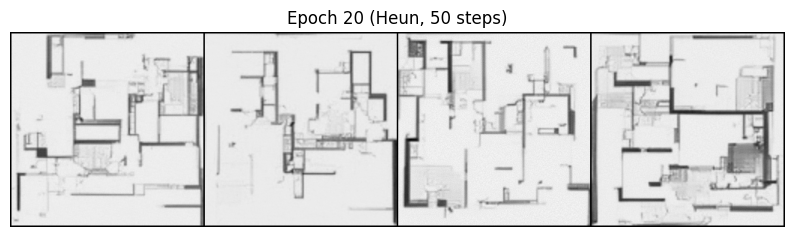

Saved: /content/floorplan_flow_model.pth


In [ ]:
# =========================
# CELL 4 — Train
# =========================

SAVE_PATH = "/content/floorplan_flow_model.pth"

def show_samples(tensor_batch, channels, title="Samples"):
    # tensor_batch: (B,C,H,W)
    x = tensor_batch.detach().cpu()
    grid = make_grid(x, nrow=min(4, x.size(0)), padding=2, normalize=True)
    plt.figure(figsize=(10, 10))
    if channels == 1:
        plt.imshow(grid.permute(1,2,0).numpy().squeeze(), cmap="gray")
    else:
        plt.imshow(grid.permute(1,2,0).numpy())
    plt.axis("off")
    plt.title(title)
    plt.show()

model.train()
for epoch in range(1, HPARAMS["epochs"] + 1):
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{HPARAMS['epochs']}")
    running = 0.0

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(HPARAMS["amp"] and device.type == "cuda")):
            loss = flow.compute_loss(model, x, y)

        scaler.scale(loss).backward()

        if HPARAMS["grad_clip"] is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), HPARAMS["grad_clip"])

        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        pbar.set_postfix(loss=loss.item())

    scheduler.step()
    avg = running / len(loader)
    print(f"Epoch {epoch} avg loss: {avg:.6f}")

    # quick sample every few epochs
    if epoch % 5 == 0:
        with torch.no_grad():
            samples = flow.sample_heun(
                model, n=4, class_idx=0,
                size=HPARAMS["img_size"],
                channels=HPARAMS["channels"],
                steps=50
            )
        show_samples(samples, HPARAMS["channels"], title=f"Epoch {epoch} (Heun, 50 steps)")

# Save final model
torch.save({
    "model_state": model.state_dict(),
    "hparams": HPARAMS
}, SAVE_PATH)
print("Saved:", SAVE_PATH)


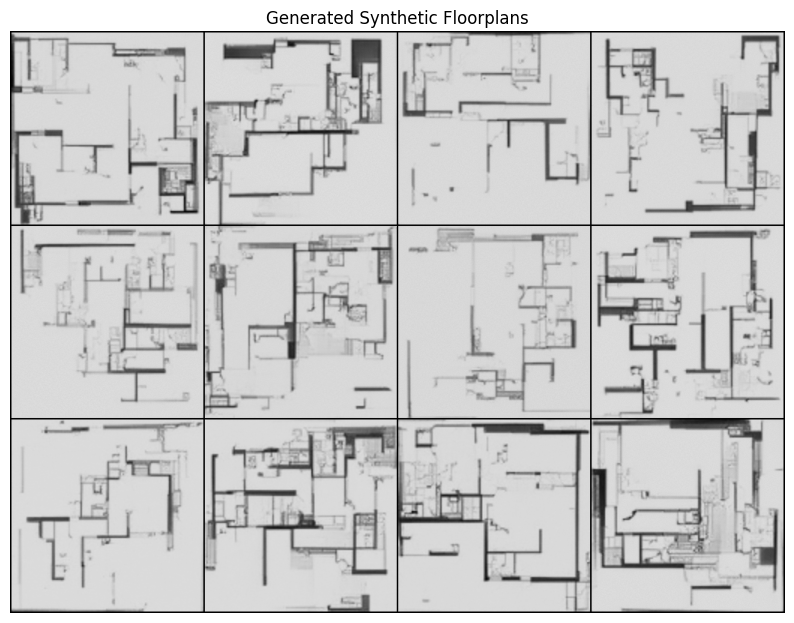

Saved samples to: /content/generated_floorplans


In [ ]:
# =========================
# CELL 5 — Load + Generate New Floorplans
# =========================

CKPT_PATH = "/content/floorplan_flow_model.pth"
ckpt = torch.load(CKPT_PATH, map_location=device)
h = ckpt["hparams"]

gen_model = ConditionalUNet(
    img_ch=h["channels"],
    base_ch=h["base_channels"],
    num_classes=h["num_classes"],
    t_dim=128
).to(device)
gen_model.load_state_dict(ckpt["model_state"])
gen_model.eval()

gen_flow = FlowMatching()

# Generate a grid of samples
with torch.no_grad():
    gen = gen_flow.sample_heun(
        gen_model, n=12, class_idx=0,
        size=h["img_size"],
        channels=h["channels"],
        steps=h["inference_steps"]
    )

# Display
x = gen.detach().cpu()
grid = make_grid(x, nrow=4, padding=2, normalize=True)
plt.figure(figsize=(10, 10))
if h["channels"] == 1:
    plt.imshow(grid.permute(1,2,0).numpy().squeeze(), cmap="gray")
else:
    plt.imshow(grid.permute(1,2,0).numpy())
plt.axis("off")
plt.title("Generated Synthetic Floorplans")
plt.show()

